In [ ]:
''' STRATEGY PERFORMANCE FOR PORTFOLIOS BASED ON CRYPTO'S MARKET CAP OR VOLUME TURNOVER '''

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
from importlib import reload
import pickle
from functools import partial
import time
import numpy as np
import pandas as pd
import multiprocessing as mp
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import math
from sklearn.linear_model import TheilSenRegressor
from sklearn.linear_model import LinearRegression

In [ ]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import norm

def sharpe_ratio_test(log_ret, value):
    '''
    Implements the sharpe ratio test from Opdyke 2007
    :param log_ret: daily log-returns
    :return: annualised sharpe ratio and p-value
    '''
    sharpe = log_ret.mean()/log_ret.std()
    sharpe_annualised = sharpe * np.sqrt(value)

    T = len(log_ret)
    std = log_ret.std()
    skew = (((log_ret - log_ret.mean()) / std) ** 3).mean()
    kurtosis = (((log_ret - log_ret.mean()) / std) ** 4).mean()

    sharpe_se = np.sqrt((1 + sharpe ** 2 / 4 * (kurtosis - 1) - sharpe * skew) / T)

    p_value = 1 - norm.cdf(sharpe/sharpe_se)

    return [sharpe_annualised.round(2), p_value]

In [ ]:
def winsorize_returns(returns, lower_percentile=1, upper_percentile=99):
    lower_bound = np.percentile(returns, lower_percentile)
    upper_bound = np.percentile(returns, upper_percentile)
    returns_clipped = np.clip(returns, lower_bound, upper_bound)
    return pd.Series(returns_clipped, index=returns.index)

Sharpe Ratio: 0.1200921015538319
Cumulative Return: 1.167355298904238 %
Daily Volatility: 1.0456676052618796 %
Daily Return: 0.006572970246825119 %
Max Drawdown: 26.1311347839401 %
Annual Compounded Return: 0.39995688977916277 %
[0.12, 0.4189262299016655]


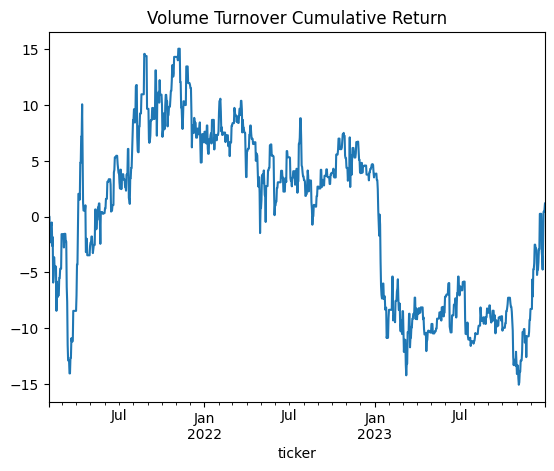

In [ ]:
'''QUANTILE STRATEGY'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def identify_quantiles(row_sums):

    row_sums = row_sums[row_sums != -1] # Eliminate tokens with no value (row-sum = 0)

    leaders_threshold = np.percentile(row_sums, 50)
    followers_threshold = np.percentile(row_sums, 50)

    leaders = row_sums[row_sums > leaders_threshold].index
    followers = row_sums[row_sums < followers_threshold].index

    return leaders, followers

def calculate_portfolio_returns(prices, portfolio):
    if len(portfolio) == 0:
        return pd.Series(index=prices.index, data=np.nan)
    returns = np.log(prices[portfolio]).diff().mean(axis=1)
    return returns

def trading_strategy(prices, market, tbill, MACD_signal, marketcap_turnover):
    prices = prices.apply(pd.to_numeric, errors='coerce')
    market = market.apply(pd.to_numeric, errors='coerce')
    tbill = tbill.apply(pd.to_numeric, errors='coerce')
    MACD_signal = MACD_signal.apply(pd.to_numeric, errors='coerce')

    # Ensure indices are datetime
    for df in [prices, market, tbill, MACD_signal, marketcap_turnover]:
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)

    prices = prices.reindex(marketcap_turnover.index)
    market = market.reindex(marketcap_turnover.index)
    tbill = tbill.reindex(marketcap_turnover.index)
    MACD_signal = MACD_signal.reindex(marketcap_turnover.index)

    returns_data = pd.DataFrame(index=prices.index)
    returns_data['market'] = np.log(market).diff().mean(axis=1)
    returns_data['tbill'] = tbill
    returns_data['MACD_signal'] = MACD_signal

    signals = pd.Series(index=prices.index)

    for date in marketcap_turnover.index:
        row = marketcap_turnover.loc[date]
        leaders, followers = identify_quantiles(row)

        if len(leaders) == 0 or len(followers) == 0:
            continue

        if date in marketcap_turnover.index:
            returns_data.at[date, 'leaders'] = calculate_portfolio_returns(prices.loc[:date], leaders).iloc[-1]
            returns_data.at[date, 'followers'] = calculate_portfolio_returns(prices.loc[:date], followers).iloc[-1]

            if returns_data.at[date, 'MACD_signal'] == 1:
               if returns_data.at[date, 'leaders'] > 0:
                    signals.at[date] = 1  # Buy followers, short leaders
               else:
                    signals.at[date] = 0
            elif returns_data.at[date, 'MACD_signal'] == -1:
               if returns_data.at[date, 'leaders'] < 0:
                    signals.at[date] = -1  # Short followers, buy leaders
               else:
                    signals.at[date] = 0
            else:
                  signals.at[date] = 0

    returns_data['signal'] = signals
    returns_data['strategy_returns'] = (
        returns_data['signal'].shift(1) * returns_data['followers'] -
        returns_data['signal'].shift(1) * returns_data['leaders']
    )

    returns_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    returns_data.dropna(subset=['leaders', 'followers', 'strategy_returns'], inplace=True)

    return returns_data

def calculate_sharpe_ratio(strategy_returns, risk_free_rate=0):
    daily_risk_free_rate = (1 + risk_free_rate)**(1/365) - 1
    excess_returns = strategy_returns - daily_risk_free_rate
    mean_excess_return = excess_returns.mean()
    std_excess_return = excess_returns.std()
    sharpe_ratio = mean_excess_return / std_excess_return
    return sharpe_ratio

def calculate_volatility(strategy_returns):
    return strategy_returns.std() * 100

def calculate_daily_return(strategy_returns):
    return strategy_returns.mean() * 100

def calculate_max_drawdown(strategy_returns):
    cumulative = (1 + strategy_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_cumulative_return(strategy_returns):
    cumulative_return = ((1 + strategy_returns).cumprod() - 1) * 100
    return cumulative_return

def calculate_annual_compounded_return(strategy_returns):
    cumulative_return = (1 + strategy_returns).cumprod()
    n_years = (strategy_returns.index[-1] - strategy_returns.index[0]).days / 365.25
    annual_compounded_return = (cumulative_return.iloc[-1] ** (1/n_years)) - 1
    return annual_compounded_return * 100

# Example usage with hypothetical `prices` and `marketcap_turnover` DataFrames
prices = pd.read_csv('/content/daily_price_file8.csv', index_col='ticker')
tbill = pd.read_csv('/content/tbill_data.csv', index_col='date')
market = pd.read_csv('market_data.csv', index_col='date')
MACD = pd.read_csv('/content/MACD.csv', index_col='date')
MACD_signal = MACD.drop(['market', 'MACD', 'Signal Line', 'MACD Histogram'], axis=1)
marketcap_turnover = pd.read_csv('/content/avg_turnover_rolling.csv', index_col='ticker') # VOLUME TURNOVER
# marketcap_turnover = pd.read_csv('/content/avg_marketcap_rolling.csv', index_col='ticker') # MARKET CAP

strategy_results = trading_strategy(prices, market, tbill, MACD_signal, marketcap_turnover)

strategy_returns = strategy_results['strategy_returns'].dropna()

strategy_returns = winsorize_returns(strategy_returns, lower_percentile=1, upper_percentile=99)

# Calculate the Sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(strategy_returns)
annualized_sharpe_ratio = sharpe_ratio * math.sqrt(365)
print("Sharpe Ratio:", annualized_sharpe_ratio)

# Calculate additional metrics
volatility = calculate_volatility(strategy_returns)
daily_return = calculate_daily_return(strategy_returns)
max_drawdown = abs(calculate_max_drawdown(strategy_returns)) * 100
cumulative_return = calculate_cumulative_return(strategy_returns)
annual_compounded_return = calculate_annual_compounded_return(strategy_returns)

print("Cumulative Return:", cumulative_return.iloc[-1], '%')
print("Daily Volatility:", volatility, '%')
print("Daily Return:", daily_return, '%')
print("Max Drawdown:", max_drawdown, '%')
print("Annual Compounded Return:", annual_compounded_return, '%')

print(sharpe_ratio_test(strategy_returns, value=365))

# Plot cumulative return
cumulative_return.plot(title='Volume Turnover Cumulative Return')
plt.show()

In [ ]:
strategy_returns.to_csv('marketcap_quantile_results.csv')

In [ ]:
file_path = './data/quantile_results.csv'
os.makedirs(os.path.dirname(file_path), exist_ok=True)
strategy_results.to_csv(file_path, index=True)
print(f"Data saved to {file_path}")

In [ ]:
def permutation_test_sharpe(prices, marketcap_turnover, n_permutations=1000, risk_free_rate=0.00):
    observed_strategy_results = trading_strategy(prices, market, tbill, MACD_signal, marketcap_turnover)
    observed_strategy_returns = observed_strategy_results['strategy_returns'].dropna()
    observed_sharpe = calculate_sharpe_ratio(observed_strategy_returns, risk_free_rate)
    permuted_sharpes = []
    for _ in range(n_permutations):
        permuted_lead_lag_matrix_rolling = marketcap_turnover.sample(frac=1).reset_index(drop=True)
        permuted_strategy_results = trading_strategy(prices, market, tbill, MACD_signal, marketcap_turnover)
        permuted_strategy_returns = permuted_strategy_results['strategy_returns'].dropna()
        permuted_sharpe = calculate_sharpe_ratio(permuted_strategy_returns, risk_free_rate)
        permuted_sharpes.append(permuted_sharpe)
    permuted_sharpes = np.array(permuted_sharpes)
    p_value = (np.sum(permuted_sharpes >= observed_sharpe) + 1) / (n_permutations + 1)
    return observed_sharpe, permuted_sharpes, p_value

prices = data
market = pd.read_csv('market_data.csv', index_col='date')
tbill = pd.read_csv('tbill_data.csv', index_col='date')
MACD = pd.read_csv('/content/MACD.csv', index_col='date')
MACD_signal = MACD.drop(['market', 'MACD', 'Signal Line', 'MACD Histogram'], axis=1)

# market = pd.read_csv('/content/Bitwise_market.csv', index_col='date')
lead_lag_rolling_matrix = lead_lag_matrix_rolling

observed_sharpe, permuted_sharpes, p_value = permutation_test_sharpe(prices, lead_lag_rolling_matrix, n_permutations=1000)
print("Observed Sharpe Ratio:", observed_sharpe)
print("P-value:", p_value)

In [ ]:
################################################################################################################################################################################################

In [ ]:
market_cap_df = pd.read_csv('/content/daily_log_marketcap.csv',index_col='ticker')
volume_cap_df = pd.read_csv('/content/daily_volume_turnover',index_col='ticker')

In [ ]:
''' HERMITIAN CLUSTERING '''

import os
import numpy as np
import pandas as pd
from sklearn import cluster
import itertools


# Normalization of adjacency matrix
def normalise_adj(A, method='rw'):
    D = np.abs(A).sum(1)

    # Replacing zero values with min in D to avoid 0/0 errors
    D = D.where(D > 0, D[D > 0].min())

    if method == 'rw':
        return np.dot(np.diag(1/D), A)
    elif method == 'sym':
        return np.diag(1/D) ** 0.5 @ A @ np.diag(1/D) ** 0.5
    else:
        raise NotImplementedError


# Spectral clustering algorithm
def spectral_cluster(A, num_clusters):
    """A is a Hermitian adj matrix"""

    # Number of eigenvectors used by the algorithm
    l = num_clusters - num_clusters % 2

    eigen_vals, eigen_vectors = np.linalg.eigh(A)

    # Indices for top l eigenvectors
    index = np.argsort(np.abs(eigen_vals))[-l:]

    col_subset = eigen_vectors[:, index]

    projection = np.dot(col_subset, np.conjugate(col_subset.T))

    return np.real(projection)


def get_clustering(market_cap_matrix, num_clusters, normalise_adj_method):
    """
    Perform clustering on the market cap matrix.

    Parameters:
    - market_cap_matrix: DataFrame where rows are dates and columns are stocks.
    - num_clusters: Number of clusters to find.
    - normalise_adj_method: Method to normalize adjacency matrix ('rw' or None).

    Returns:
    - clusters: Series with stock tickers as index and cluster labels as values.
    """

    # Compute the adjacency matrix (e.g., using correlation)
    correlation_matrix = market_cap_matrix.corr()

    # Convert correlation matrix to a Hermitian adjacency matrix
    A = correlation_matrix * complex(0, 1)

    if normalise_adj_method is not None:
        A = normalise_adj(A, method=normalise_adj_method)

    projection = spectral_cluster(A, num_clusters)
    clustering = cluster.KMeans(n_clusters=num_clusters, n_init=200, max_iter=6000).fit(projection)
    clusters = pd.Series(clustering.labels_, index=market_cap_matrix.columns)

    return clusters


def get_ordered_clustering(market_cap_matrix, num_clusters):
    """
    Returns a clustering of stocks based on their market cap series where
    the node label corresponds to the clusters (where 0 is the most leading and
    (num_clusters - 1) is the least leading cluster).
    RW-normalized Hermitian clustering is performed.

    Parameters:
    - market_cap_matrix: DataFrame where rows are dates and columns are stocks.
    - num_clusters: Number of clusters to find.

    Returns:
    - Ordered clusters with 0 as most leading and num_clusters-1 as least leading.
    """
    clustering = get_clustering(market_cap_matrix, num_clusters, 'rw')

    lead_lag_by_stock = market_cap_matrix.sum(axis=0)
    lead_lag_by_cluster = lead_lag_by_stock.groupby(clustering).mean()
    map_cluster_to_order = lead_lag_by_cluster.rank(ascending=False).map(lambda num: int(num) - 1)
    clustering = clustering.map(map_cluster_to_order)

    return clustering

num_clusters = 6
ordered_clusters = get_ordered_clustering(market_cap_df, num_clusters) # volume_cap_df

print(ordered_clusters)

ROSE    2
ANKR    2
VET     5
NEAR    2
ETH     2
       ..
AAVE    1
DOGE    1
NEO     1
SAND    0
QTUM    1
Length: 72, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import pickle
from sklearn.cluster import KMeans

# Fill NaNs in market_cap_df
market_cap_df = market_cap_df.fillna(0)

def construct_difference_matrix(market_cap_df):
    """
    Constructs a difference matrix based on market cap differences.

    Parameters:
    - market_cap_df: DataFrame with dates as index and stocks as columns.

    Returns:
    - difference_matrix: DataFrame with pairwise differences.
    """
    # Calculate the mean market cap over the window period for each stock
    mean_market_caps = market_cap_df.mean()

    mean_market_caps = mean_market_caps.values

    difference_matrix = mean_market_caps[:, np.newaxis] - mean_market_caps[np.newaxis, :]

    difference_matrix = pd.DataFrame(difference_matrix, index=market_cap_df.columns, columns=market_cap_df.columns)

    difference_matrix = difference_matrix.fillna(0)

    return difference_matrix

def rolling_difference_matrix(market_cap_df, window=30):
    """
    Constructs rolling difference matrices.

    Parameters:
    - market_cap_df: DataFrame with dates as index and stocks as columns.
    - window: Lookback window size.

    Returns:
    - rolling_matrices: A dictionary with dates as keys and difference matrices as values.
    """
    # Ensure the index is a DatetimeIndex
    market_cap_df.index = pd.to_datetime(market_cap_df.index)

    rolling_matrices = {}

    for end_date in market_cap_df.index[window-1:]:
        start_date = end_date - pd.Timedelta(days=window-1)
        window_data = market_cap_df.loc[start_date:end_date]
        difference_matrix = construct_difference_matrix(window_data)
        rolling_matrices[end_date] = difference_matrix

    return rolling_matrices

def apply_hermitian_clustering_on_rolling_basis(market_cap_df, num_clusters, window=30):
    """
    Apply Hermitian clustering on a rolling basis.

    Parameters:
    - market_cap_df: DataFrame with dates as index and stocks as columns.
    - num_clusters: Number of clusters.
    - window: Lookback window size.

    Returns:
    - daily_clusters: A dictionary with dates as keys and cluster labels as values.
    """
    rolling_matrices = rolling_difference_matrix(market_cap_df, window=window)
    daily_clusters = {}

    for date, diff_matrix in rolling_matrices.items():
        # Apply Hermitian clustering on the difference matrix
        clusters = get_ordered_clustering(diff_matrix, num_clusters)
        daily_clusters[date] = clusters

    return daily_clusters

num_clusters = 6
daily_clusters = apply_hermitian_clustering_on_rolling_basis(market_cap_df, num_clusters, window=30) # volume_cap_df

with open("/content/daily_clusters.pkl", "wb") as file:
    pickle.dump(daily_clusters, file)

In [ ]:
cluster_rolling = pd.read_pickle('/content/daily_clusters.pkl')

In [ ]:
import pandas as pd

# Load the clusters from the pickle file (already done)
clusters_rolling = pd.read_pickle('/content/market_cap_clusters.pkl')

df_clustering = pd.DataFrame(clusters_rolling).T

df_clustering.reset_index(inplace=True)
df_clustering.rename(columns={'index': 'Date'}, inplace=True)

print(df_clustering)

Date  Date  2021-01-30 00:00:00  2021-01-31 00:00:00  2021-02-01 00:00:00  \
0     ROSE                    2                    2                    2   
1     ANKR                    2                    2                    2   
2      VET                    2                    2                    2   
3     NEAR                    2                    2                    2   
4      ETH                    2                    2                    2   
..     ...                  ...                  ...                  ...   
67    AAVE                    3                    3                    4   
68    DOGE                    3                    3                    4   
69     NEO                    3                    3                    4   
70    SAND                    3                    3                    4   
71    QTUM                    3                    3                    4   

Date  2021-02-02 00:00:00  2021-02-03 00:00:00  2021-02-04 00:00:00  \
0   

In [ ]:
df_clustering.set_index('Date', inplace=True)

In [ ]:
df_clustering.index = pd.to_datetime(df_clustering.index)

In [ ]:
df_clustering.to_csv('/content/daily_clusters.csv')

In [ ]:
df_clustering.to_pickle('/content/daily_clusters.pkl')

Sharpe Ratio: 0.17991782776721596
Cumulative Return: 5.70280911459764 %
Daily Volatility: 0.9094612545542372 %
Daily Return: 0.008564696315610566 %
Max Drawdown: 31.754759723522163 %
Annual Compounded Return: 1.6390689185969531 %


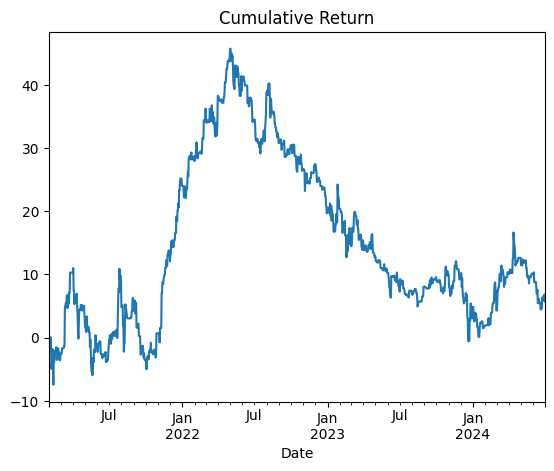

In [ ]:
'''CLUSTERED STRATEGY'''

import pandas as pd
import numpy as np

def identify_clusters(clusters_rolling, date):
    """
    Identify leaders and followers based on clustering information.
    """
    clusters = clusters_rolling.loc[date]
    leaders = clusters[(clusters == 0) | (clusters == 1) ].index
    followers = clusters[(clusters == 5) | (clusters == 4) ].index

    return leaders, followers

def calculate_portfolio_returns(prices, portfolio):
    if len(portfolio) == 0:
        return pd.Series(index=prices.index, data=np.nan)
    returns = np.log(prices[portfolio]).diff().mean(axis=1)
    return returns

def trading_strategy(prices, market, tbill, MACD_signal, clusters_rolling):
    # Ensure all data is numeric
    prices = prices.apply(pd.to_numeric, errors='coerce')
    market = market.apply(pd.to_numeric, errors='coerce')
    tbill = tbill.apply(pd.to_numeric, errors='coerce')
    MACD_signal = MACD_signal.apply(pd.to_numeric, errors='coerce')

    # Convert index to DatetimeIndex if not already
    if not isinstance(prices.index, pd.DatetimeIndex):
        prices.index = pd.to_datetime(prices.index)
    if not isinstance(market.index, pd.DatetimeIndex):
        market.index = pd.to_datetime(market.index)
    if not isinstance(tbill.index, pd.DatetimeIndex):
        tbill.index = pd.to_datetime(tbill.index)
    if not isinstance(MACD_signal.index, pd.DatetimeIndex):
        MACD_signal.index = pd.to_datetime(MACD_signal.index)
    if not isinstance(clusters_rolling.index, pd.DatetimeIndex):
        clusters_rolling.index = pd.to_datetime(clusters_rolling.index)

    # Reindex prices and market to align with clusters_rolling index
    prices = prices.reindex(clusters_rolling.index)
    market = market.reindex(clusters_rolling.index)
    tbill = tbill.reindex(clusters_rolling.index)
    MACD_signal = MACD_signal.reindex(clusters_rolling.index)
    clusters_rolling = clusters_rolling.reindex(clusters_rolling.index)

    # Prepare DataFrame to store returns and signals
    returns_data = pd.DataFrame(index=prices.index)
    returns_data['market'] = np.log(market).diff().mean(axis=1)  # Market returns
    returns_data['tbill'] = tbill
    returns_data['MACD_signal'] = MACD_signal

    signals = pd.Series(index=prices.index)

    for date in clusters_rolling.index:
        # Identify leaders and followers based on clustering
        leaders, followers = identify_clusters(clusters_rolling, date)

        if len(leaders) == 0 or len(followers) == 0:
            continue  # Skip if no leaders or followers identified

        # Calculate returns for leaders and followers
        if date in clusters_rolling.index:
            returns_data.at[date, 'leaders'] = calculate_portfolio_returns(prices.loc[:date], leaders).iloc[-1]
            returns_data.at[date, 'followers'] = calculate_portfolio_returns(prices.loc[:date], followers).iloc[-1]

            if returns_data.at[date, 'MACD_signal'] == 1:
                if returns_data.at[date, 'leaders'] > 0:
                    signals.at[date] = 1  # Buy followers, short leaders
                else:
                    signals.at[date] = 0
            elif returns_data.at[date, 'MACD_signal'] == -1:
                if returns_data.at[date, 'leaders'] < 0:
                    signals.at[date] = -1  # Short followers, buy leaders
                else:
                    signals.at[date] = 0
            else:
                signals.at[date] = 0

    # Ensure that 'followers' and 'leaders' columns are created
    if 'followers' not in returns_data.columns:
        returns_data['followers'] = np.nan
    if 'leaders' not in returns_data.columns:
        returns_data['leaders'] = np.nan

    # Calculate strategy returns
    returns_data['signal'] = signals
    returns_data['strategy_returns'] = (
        returns_data['signal'].shift(1) * returns_data['followers'] -
        returns_data['signal'].shift(1) * returns_data['leaders']
    )

    return returns_data

def calculate_sharpe_ratio(strategy_returns, risk_free_rate=0.00):
    # Assume the risk-free rate is annual, convert it to daily
    daily_risk_free_rate = (1 + risk_free_rate)**(1/365) - 1

    # Calculate excess returns
    excess_returns = strategy_returns - daily_risk_free_rate

    # Calculate average excess return and standard deviation of excess returns
    mean_excess_return = excess_returns.mean()
    std_excess_return = excess_returns.std()

    # Calculate Sharpe ratio
    sharpe_ratio = mean_excess_return / std_excess_return

    return sharpe_ratio

def calculate_volatility(strategy_returns):
    return strategy_returns.std() * 100

def calculate_daily_return(strategy_returns):
    return strategy_returns.mean() * 100  # Basis points

def calculate_max_drawdown(strategy_returns):
    cumulative = (1 + strategy_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_cumulative_return(strategy_returns):
    cumulative_return = ((1 + strategy_returns).cumprod() - 1) * 100
    return cumulative_return

def calculate_annual_compounded_return(strategy_returns):
    cumulative_return = (1 + strategy_returns).cumprod()
    n_years = (strategy_returns.index[-1] - strategy_returns.index[0]).days / 365.25
    annual_compounded_return = (cumulative_return.iloc[-1] ** (1/n_years)) - 1
    return annual_compounded_return * 100

# Example usage with hypothetical `prices` and `lead_lag_rolling_matrix` DataFrames
prices = pd.read_csv('/content/daily_price.csv', index_col='ticker')
tbill = pd.read_csv('/content/tbill_data.csv', index_col='date')
market = pd.read_csv('market_data.csv', index_col='date')
MACD = pd.read_csv('/content/MACD.csv', index_col='date')
MACD_signal = MACD.drop(['market', 'MACD', 'Signal Line', 'MACD Histogram'], axis=1)

clusters_rolling = pd.read_pickle('/content/volume_turnover_clusters.pkl')

strategy_results = trading_strategy(prices, market, tbill, MACD_signal, clusters_rolling)

strategy_returns = strategy_results['strategy_returns'].dropna()

# Calculate the Sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(strategy_results['strategy_returns'].dropna())
annualized_sharpe_ratio = sharpe_ratio * math.sqrt(365) # CHANGE THIS ACCORDING TO THE LEVEL OF DATA
print("Sharpe Ratio:", annualized_sharpe_ratio)

# Calculate additional metrics
volatility = calculate_volatility(strategy_returns)
daily_return = calculate_daily_return(strategy_returns)
max_drawdown = abs(calculate_max_drawdown(strategy_returns)) * 100
cumulative_return = calculate_cumulative_return(strategy_returns)
annual_compounded_return = calculate_annual_compounded_return(strategy_returns)

if strategy_returns.empty:
    print("No valid strategy returns available.")
else:
    cumulative_return = calculate_cumulative_return(strategy_returns)
    print("Cumulative Return:", cumulative_return.iloc[-1], '%')  # Print the final cumulative return value

print("Daily Volatility:", volatility, '%')
print("Daily Return:", daily_return, '%')
print("Max Drawdown:", max_drawdown, '%')
print("Annual Compounded Return:", annual_compounded_return, '%')

# Plot cumulative return
cumulative_return.plot(title='Cumulative Return')
plt.show()

In [ ]:
strategy_returns.to_csv('turnover_hermitian_results.csv')

In [ ]:
file_path = './data/hermitian_results.csv'
os.makedirs(os.path.dirname(file_path), exist_ok=True)
strategy_results.to_csv(file_path, index=True)
print(f"Data saved to {file_path}")

Data saved to ./data/hermitian_results.csv


In [ ]:
def permutation_test_sharpe(prices, marketcap_turnover, n_permutations=1000, risk_free_rate=0.00):
    observed_strategy_results = trading_strategy(prices, market, tbill, MACD_signal, marketcap_turnover)
    observed_strategy_returns = observed_strategy_results['strategy_returns'].dropna()
    observed_sharpe = calculate_sharpe_ratio(observed_strategy_returns, risk_free_rate)
    permuted_sharpes = []
    for _ in range(n_permutations):
        permuted_lead_lag_matrix_rolling = marketcap_turnover.sample(frac=1).reset_index(drop=True)
        permuted_strategy_results = trading_strategy(prices, market, tbill, MACD_signal, marketcap_turnover)
        permuted_strategy_returns = permuted_strategy_results['strategy_returns'].dropna()
        permuted_sharpe = calculate_sharpe_ratio(permuted_strategy_returns, risk_free_rate)
        permuted_sharpes.append(permuted_sharpe)
    permuted_sharpes = np.array(permuted_sharpes)
    p_value = (np.sum(permuted_sharpes >= observed_sharpe) + 1) / (n_permutations + 1)
    return observed_sharpe, permuted_sharpes, p_value

prices = data
market = pd.read_csv('market_data.csv', index_col='date')
tbill = pd.read_csv('tbill_data.csv', index_col='date')
MACD = pd.read_csv('/content/MACD.csv', index_col='date')
MACD_signal = MACD.drop(['market', 'MACD', 'Signal Line', 'MACD Histogram'], axis=1)

# market = pd.read_csv('/content/Bitwise_market.csv', index_col='date')
lead_lag_rolling_matrix = lead_lag_matrix_rolling

observed_sharpe, permuted_sharpes, p_value = permutation_test_sharpe(prices, lead_lag_rolling_matrix, n_permutations=1000)
print("Observed Sharpe Ratio:", observed_sharpe)
print("P-value:", p_value)

In [ ]:
'''

CALCULATE ADJUSTED RAND INDEX

'''

In [ ]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score

def calculate_daily_ari(df1, df2):
    """
    Calculate the daily Adjusted Rand Index (ARI) between two clustering dataframes, ignoring NaN values.

    Parameters:
    - df1: DataFrame with clusters based on market_cap
    - df2: DataFrame with clusters based on volume_turnover

    Returns:
    - daily_ari: A DataFrame with the ARI for each day.
    - avg_ari: The average daily ARI.
    """
    ari_scores = []

    df1 = df1.reindex(df2.index)
    df2 = df2.reindex(df1.index)
    df1 = df1[df1.columns.intersection(df2.columns)]
    df2 = df2[df2.columns.intersection(df1.columns)]

    for date in df1.index:
        # Get the clustering labels for each day
        cluster_labels_1 = df1.loc[date]
        cluster_labels_2 = df2.loc[date]

        # Drop stocks with NaN values from both dataframes
        valid_indices = ~cluster_labels_1.isna() & ~cluster_labels_2.isna()
        cluster_labels_1 = cluster_labels_1[valid_indices]
        cluster_labels_2 = cluster_labels_2[valid_indices]

        if len(cluster_labels_1) > 0 and len(cluster_labels_2) > 0:
            # Calculate ARI for the day
            ari = adjusted_rand_score(cluster_labels_1, cluster_labels_2)
            ari_scores.append(ari)
        else:
            ari_scores.append(float('nan'))

    daily_ari = pd.DataFrame({'Date': df1.index, 'ARI': ari_scores}).set_index('Date')

    avg_ari = pd.Series(ari_scores).mean()

    return daily_ari, avg_ari

df1 = pd.read_pickle('/content/clustering/market_cap_clusters.pkl')
df2 = pd.read_pickle('/content/clustering/volume_turnover_clusters.pkl')

df1.index = pd.to_datetime(df1.index)
df2.index = pd.to_datetime(df2.index)

daily_ari, avg_ari = calculate_daily_ari(df1, df2)
print("Average Daily Adjusted Rand Index (ARI):", avg_ari)
print(daily_ari)

Average Daily Adjusted Rand Index (ARI): 0.8826501674273584
                 ARI
Date                
2021-01-30  0.779327
2021-01-31  0.898610
2021-02-01  0.867161
2021-02-02  0.868789
2021-02-03  0.901592
...              ...
2024-06-26  0.898610
2024-06-27  0.967197
2024-06-28  0.835986
2024-06-29  0.898610
2024-06-30  0.964215

[1248 rows x 1 columns]


In [ ]:
import numpy as np
import pandas as pd

def identify_quantiles(lead_lag_matrix):
    row_sums = lead_lag_matrix.sum(axis=1)
    leaders_threshold = np.percentile(row_sums, 50)
    followers_threshold = np.percentile(row_sums, 50)

    leaders = row_sums[row_sums >= leaders_threshold].index
    followers = row_sums[row_sums <= followers_threshold].index

    return leaders, followers

daily_leaders_followers = {
    'date': [],
    'leaders': [],
    'followers': []
}

lead_lag_matrix_rolling = pd.read_pickle('/content/rolling_matrix/lead_lag_matrix_rolling_lookback_30_update_freq_0_mutual_information_ccf_at_max_lag.pkl') # There are a number of lead_lag files to work with

# Iterate over each date
for date in lead_lag_matrix_rolling.index:
    lead_lag_matrix = lead_lag_matrix_rolling.loc[date]

    # Identify leaders and followers for the current day
    leaders, followers = identify_quantiles(lead_lag_matrix)

    daily_leaders_followers['date'].append(date)
    daily_leaders_followers['leaders'].append(leaders.tolist())
    daily_leaders_followers['followers'].append(followers.tolist())

daily_leaders_followers_df = pd.DataFrame(daily_leaders_followers)

print(daily_leaders_followers_df)

           date                                            leaders  \
0    2021-01-31  [ROSE, NEAR, INJ, MATIC, BCH, IOST, EGLD, HBAR...   
1    2021-02-01  [ROSE, NEAR, INJ, BCH, IOST, EGLD, HBAR, ZIL, ...   
2    2021-02-02  [ROSE, NEAR, ETH, INJ, BCH, IOST, EGLD, HBAR, ...   
3    2021-02-03  [VET, NEAR, INJ, BCH, IOST, EGLD, HBAR, ALGO, ...   
4    2021-02-04  [VET, NEAR, ETH, REEF, INJ, FIL, BCH, EGLD, HB...   
...         ...                                                ...   
1242 2024-06-26  [ROSE, VET, NEAR, BAKE, INJ, MATIC, IOST, CHR,...   
1243 2024-06-27  [BAKE, GRT, INJ, MATIC, BCH, CHR, HBAR, DASH, ...   
1244 2024-06-28  [ROSE, VET, BAKE, GRT, INJ, FIL, MATIC, CHR, H...   
1245 2024-06-29  [ETH, GRT, INJ, MATIC, IOST, CHR, HBAR, DASH, ...   
1246 2024-06-30  [VET, NEAR, EOS, GRT, INJ, CHR, HBAR, ZIL, ALI...   

                                              followers  
0     [ANKR, VET, ETH, EOS, GRT, REEF, FIL, CHR, ALG...  
1     [ANKR, VET, ETH, EOS, GRT, REEF, MATI

Each Lead-lag files represents by df1, df2,...

In [ ]:
df1 = daily_leaders_followers_df

In [ ]:
df2 = daily_leaders_followers_df

In [ ]:
df3 = daily_leaders_followers_df

In [ ]:
df4 = daily_leaders_followers_df

In [ ]:
import numpy as np
import pandas as pd

def identify_quantiles(row):
    """
    Identify leaders and followers based on quantiles.
    """
    row = pd.to_numeric(row, errors='coerce')

    row = row.dropna()

    if len(row) == 0:

        return [], []

    leaders_threshold = np.percentile(row, 60)
    followers_threshold = np.percentile(row, 40)

    leaders = row[row >= leaders_threshold].index.tolist()
    followers = row[row <= followers_threshold].index.tolist()

    return leaders, followers

daily_leaders_followers = {
    'date': [],
    'leaders': [],
    'followers': []
}

# Load the market_cap or volume_turnover DataFrame
market_cap_df = pd.read_csv('/content/daily_volume_turnover.csv', index_col='date')  # Update path to your actual data

if not isinstance(market_cap_df.index, pd.DatetimeIndex):
    market_cap_df.index = pd.to_datetime(market_cap_df.index)

# Iterate over each date in the dataframe
for date in market_cap_df.index:

    if not isinstance(date, pd.Timestamp):
        date = pd.to_datetime(date, errors='coerce')

    row = market_cap_df.loc[date]

    # Identify leaders and followers for the current day
    leaders, followers = identify_quantiles(row)

    daily_leaders_followers['date'].append(date)
    daily_leaders_followers['leaders'].append(leaders)
    daily_leaders_followers['followers'].append(followers)

daily_leaders_followers_df = pd.DataFrame(daily_leaders_followers)

daily_leaders_followers_df['date'] = pd.to_datetime(daily_leaders_followers_df['date'], errors='coerce')

daily_leaders_followers_df['date'] = daily_leaders_followers_df['date'].dt.date

print(daily_leaders_followers_df)

            date                                            leaders  \
0     2021-01-01  [ROSE, NEAR, GRT, REEF, INJ, FIL, CHR, EGLD, Z...   
1     2021-01-02  [ROSE, GRT, REEF, INJ, MATIC, IOST, CHR, EGLD,...   
2     2021-01-03  [ROSE, VET, GRT, REEF, INJ, MATIC, IOST, ZIL, ...   
3     2021-01-04  [ROSE, GRT, REEF, INJ, MATIC, IOST, CHR, EGLD,...   
4     2021-01-05  [ROSE, VET, GRT, REEF, INJ, MATIC, IOST, EGLD,...   
...          ...                                                ...   
1272  2024-06-26  [ROSE, ANKR, NEAR, BAKE, REEF, INJ, FIL, IOST,...   
1273  2024-06-27  [ROSE, NEAR, EOS, BAKE, REEF, INJ, CHR, ZIL, D...   
1274  2024-06-28  [ROSE, NEAR, EOS, BAKE, REEF, INJ, FIL, CHR, D...   
1275  2024-06-29  [ROSE, EOS, BAKE, REEF, INJ, CHR, ZIL, DENT, A...   
1276  2024-06-30  [ROSE, NEAR, EOS, BAKE, REEF, INJ, FIL, CHR, Z...   

                                              followers  
0     [ETH, EOS, BCH, HBAR, DENT, IOTA, LINK, XTZ, L...  
1     [ETH, EOS, FIL, BCH, HBAR

In [ ]:
df5 = daily_leaders_followers_df

In [ ]:
df6 = daily_leaders_followers_df

In [ ]:
'''

JACCARD SCORE CALCULATION

'''

In [ ]:
import numpy as np
import pandas as pd

def jaccard_coefficient(set1, set2):
    """
    Compute the Jaccard coefficient between two sets.
    """
    set1 = set(set1)
    set2 = set(set2)
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

def compute_daily_jaccard(daily_leaders_followers_df1, daily_leaders_followers_df2):
    """
    Compute the daily Jaccard coefficients between two DataFrames containing leaders and followers.
    """
    daily_leaders_followers_df1 = daily_leaders_followers_df1.set_index('date')
    daily_leaders_followers_df2 = daily_leaders_followers_df2.set_index('date')

    daily_leaders_followers_df1, daily_leaders_followers_df2 = daily_leaders_followers_df1.align(daily_leaders_followers_df2, join='inner')

    # List to store Jaccard coefficients for each day
    jaccard_scores = []

    for date in daily_leaders_followers_df1.index:
        leaders1 = daily_leaders_followers_df1.loc[date, 'leaders']
        followers1 = daily_leaders_followers_df1.loc[date, 'followers']
        leaders2 = daily_leaders_followers_df2.loc[date, 'leaders']
        followers2 = daily_leaders_followers_df2.loc[date, 'followers']

        # Calculate Jaccard coefficient for leaders and followers separately
        jaccard_leaders = jaccard_coefficient(leaders1, leaders2)
        jaccard_followers = jaccard_coefficient(followers1, followers2)

        # Combine the results
        jaccard_scores.append({
            'date': date,
            'jaccard_leaders': jaccard_leaders,
            'jaccard_followers': jaccard_followers
        })

    jaccard_df = pd.DataFrame(jaccard_scores)

    # Calculate average Jaccard coefficients
    average_jaccard_leaders = jaccard_df['jaccard_leaders'].mean()
    average_jaccard_followers = jaccard_df['jaccard_followers'].mean()

    return average_jaccard_leaders, average_jaccard_followers

# Compute the daily Jaccard coefficients
average_jaccard_leaders, average_jaccard_followers = compute_daily_jaccard(df1, df2)

average_jaccard=(average_jaccard_leaders + average_jaccard_followers)/2

print(f"Average Daily Jaccard Coefficient for Leaders: {average_jaccard_leaders:.4f}")
print(f"Average Daily Jaccard Coefficient for Followers: {average_jaccard_followers:.4f}")

print(f"Average Daily Jaccard Coefficient: {average_jaccard:.4f}")

Average Daily Jaccard Coefficient for Leaders: 0.1057
Average Daily Jaccard Coefficient for Followers: 0.0955
Average Daily Jaccard Coefficient: 0.1006
